In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path("/Users/radinabakalov/TECHTRACK-RADINABAKALOV")
sys.path.append(str(REPO_ROOT))

In [2]:
import os
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from techtrack.modules.inference.model import Detector
from techtrack.modules.inference.nms import NMS

# Paths

# Where the raw logistics images (and their YOLO labels) live
DATA_DIR = REPO_ROOT / "techtrack" / "storage" / "logistics"

# The pre-built sample list from our sampling script
SAMPLE_LIST = REPO_ROOT / "analysis" / "sample_images.txt"

# We have two YOLO model checkpoints to compare
MODEL1_DIR = REPO_ROOT / "techtrack" / "storage" / "yolo_model_1"
MODEL2_DIR = REPO_ROOT / "techtrack" / "storage" / "yolo_model_2"

# Cache folder for storing intermediate results so we don't
# have to re-run expensive inference every time
CACHE_DIR = REPO_ROOT / "analysis" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Quick checks to make sure the key paths actually exist
print("DATA_DIR exists:", DATA_DIR.exists())
print("sample list exists:", SAMPLE_LIST.exists())
print("cache dir:", CACHE_DIR)

DATA_DIR exists: True
sample list exists: True
cache dir: /Users/radinabakalov/TECHTRACK-RADINABAKALOV/analysis/cache


In [3]:
def load_sample_list(sample_list_path: Path):
    """Read the saved list of image paths from our sampling script."""
    with open(sample_list_path, "r") as f:
        # Drop any blank lines or trailing whitespace
        paths = [line.strip() for line in f if line.strip()]
    # Convert each string path into a proper Path object
    return [Path(p) for p in paths]

# Full dataset list 
image_paths = sorted(DATA_DIR.glob("*.jpg"))

# Quick checks
print("Loaded sample images:", len(image_paths))
print("First image:", image_paths[0])
print("First image exists:", image_paths[0].exists())

Loaded sample images: 9525
First image: /Users/radinabakalov/TECHTRACK-RADINABAKALOV/techtrack/storage/logistics/-01-15-1-1-1-2-26_jpg.rf.eb62a0a5f84fcbdbc0910af072cf0072.jpg
First image exists: True


In [4]:
def yolo_txt_to_boxes(txt_path: Path, img_w: int, img_h: int):
    """
    Parse a YOLO .txt label file into pixel-space bounding boxes.
    Returns (gt_boxes, gt_classes) where boxes are [x, y, w, h] in pixels.
    """
    # If there's no label file, this image has no annotations
    if not txt_path.exists():
        return [], []

    gt_boxes = []
    gt_classes = []

    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            # Each valid YOLO line has exactly 5 values (class cx cy w h)
            if len(parts) != 5:
                continue

            cls = int(float(parts[0]))
            # YOLO stores coordinates as normalized center-x, center-y, width, height
            cx, cy, w, h = map(float, parts[1:])

            # Convert from normalized center format to pixel corner format
            # (top-left x, top-left y, box width, box height)
            bw = int(round(w * img_w))
            bh = int(round(h * img_h))
            x = int(round((cx * img_w) - bw / 2))
            y = int(round((cy * img_h) - bh / 2))

            gt_boxes.append([x, y, bw, bh])
            gt_classes.append(cls)

    return gt_boxes, gt_classes


def get_label_path(img_path: Path):
    """Swap .jpg to .txt to find the matching YOLO label file."""
    return img_path.with_suffix(".txt")

In [5]:
def iou_xywh(a, b):
    """Compute Intersection over Union for two boxes in [x, y, w, h] format."""
    # Unpack both boxes
    ax, ay, aw, ah = a
    bx, by, bw, bh = b

    # Get the bottom-right corners of each box
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    # Find the overlap rectangle (if any)
    ix1 = max(ax, bx)
    iy1 = max(ay, by)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # To zero (if the boxes don't overlap, the width/height will be negative)
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Union = both areas combined, minus the overlap we counted twice
    union = max(0, aw) * max(0, ah) + max(0, bw) * max(0, bh) - inter
    
    # Avoid division by zero if something slipped in
    return (inter / union) if union > 0 else 0.0

In [6]:
def run_detector_on_image(detector: Detector, nms: NMS, img_path: Path):
    """
    Run one YOLO detector on a single image, apply NMS,
    and return the cleaned up detections as a dict.
    Returns None if the image couldn't be loaded.
    """
    # Load the image from disk (OpenCV needs a string path)
    img = cv2.imread(str(img_path))

    # Sometimes images are corrupt or missing (bail out)
    if img is None:
        return None

    # Run the forward pass through the YOLO model
    outputs = detector.predict(img)

    # Post-process raw network outputs into usable boxes, classes, and scores
    bboxes, class_ids, scores, cls_scores = detector.post_process(outputs)

    # Apply NMS to remove overlapping duplicate detections
    bboxes, class_ids, scores, cls_scores = nms.filter(bboxes, class_ids, scores, cls_scores)

    # Bundle everything into a dict, including image dimensions
    # (we'll need those later for converting between coordinate formats)
    return {
        "bboxes": bboxes,
        "class_ids": class_ids,
        "scores": scores,
        "cls_scores": cls_scores,
        "img_w": img.shape[1],
        "img_h": img.shape[0],
    }


In [7]:
# Detection thresholds 
# Only keep detections the model is at least 50% confident about
SCORE_THRESHOLD = 0.5
# NMS overlap cutoff so that if two boxes overlap more than 40%, we drop the weaker one
NMS_IOU_THRESHOLD = 0.4

def build_detector(model_dir: Path, suffix: str):
    """
    Assemble a Detector from the weights, config, and class names inside a given model directory. 
    The suffix ("1" or "2") picks which checkpoint variant to load.
    """
    weights = model_dir / f"yolov4-tiny-logistics_size_416_{suffix}.weights"
    cfg = model_dir / f"yolov4-tiny-logistics_size_416_{suffix}.cfg"
    names = model_dir / "logistics.names"
    return Detector(str(weights), str(cfg), str(names), score_threshold=SCORE_THRESHOLD)

# Use both model variants so we can compare them head-to-head
det1 = build_detector(MODEL1_DIR, "1")
det2 = build_detector(MODEL2_DIR, "2")

# Both models use the same filtering thresholds
nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=NMS_IOU_THRESHOLD)

print("Models loaded.")


Models loaded.


In [8]:
def cache_path_for(model_name: str):
    """Build the pickle cache path for a given model's predictions."""
    return CACHE_DIR / f"{model_name}_FULL_preds.pkl"

def run_and_cache(model_name: str, detector: Detector, image_paths):
    """
    Run a detector across all sample images and cache the results.
    If we've already done this before, just load from the pickle file instead of re-running inference (saves ~4 minutes per model).
    """
    out_path = cache_path_for(model_name)

    # If we already have cached predictions, skip the heavy lifting
    if out_path.exists():
        with open(out_path, "rb") as f:
            return pickle.load(f)

    # No cache, so we run inference on every image in the sample
    preds = []
    for i, p in enumerate(image_paths, 1):
        pred = run_detector_on_image(detector, nms, p)
        preds.append({"img_path": str(p), "pred": pred})

        # Print progress every 200 images so we know it's not stuck
        if i % 200 == 0:
            print(f"{model_name}: {i}/{len(image_paths)}")

    # Save predictions so future runs are instant
    with open(out_path, "wb") as f:
        pickle.dump(preds, f)

    return preds

preds1 = run_and_cache("model1", det1, image_paths)
preds2 = run_and_cache("model2", det2, image_paths)

# Run both models (or load from cache if we've done this already)
print("Cached:", cache_path_for("model1"))
print("Cached:", cache_path_for("model2"))

Cached: /Users/radinabakalov/TECHTRACK-RADINABAKALOV/analysis/cache/model1_FULL_preds.pkl
Cached: /Users/radinabakalov/TECHTRACK-RADINABAKALOV/analysis/cache/model2_FULL_preds.pkl


In [9]:
def eval_predictions(preds, iou_thr=0.5, num_classes=20):
    """
    Evaluate a set of model predictions against ground truth labels.
    Uses greedy IoU matching to count true positives, false positives, and false negatives per class, then computes precision/recall/F1.
    """
    # Per-class counters for the confusion breakdown
    tp = np.zeros(num_classes, dtype=int) # correctly detected
    fp = np.zeros(num_classes, dtype=int) # predicted but wrong
    fn = np.zeros(num_classes, dtype=int) # missed entirely

    for row in preds:
        img_path = Path(row["img_path"])
        pred = row["pred"]

        # We need the image dimensions to convert YOLO labels to pixel coords
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img_h, img_w = img.shape[0], img.shape[1]
        gt_boxes, gt_classes = yolo_txt_to_boxes(get_label_path(img_path), img_w, img_h)

        # If the detector returned nothing, every ground truth box is a miss
        if pred is None:
            for c in gt_classes:
                fn[c] += 1
            continue

        pred_boxes = pred["bboxes"]
        pred_classes = pred["class_ids"]

        # Track which ground truth boxes have already been claimed
        matched_gt = [False] * len(gt_boxes)

        # Greedy matching
        # For each predicted box, find the best-overlapping GT box of the same class that hasn't been matched yet
        for pb, pc in zip(pred_boxes, pred_classes):
            best_iou = 0.0
            best_j = -1

            for j, (gb, gc) in enumerate(zip(gt_boxes, gt_classes)):
                # Skip GTs that are already taken or a different class
                if matched_gt[j]:
                    continue
                if gc != pc:
                    continue

                cur_iou = iou_xywh(pb, gb)
                if cur_iou > best_iou:
                    best_iou = cur_iou
                    best_j = j

            # Good enough overlap? Count it as a hit
            if best_iou >= iou_thr and best_j != -1:
                tp[pc] += 1
                matched_gt[best_j] = True
            else:
                # Either no match or IoU too low, then it's a false positive
                fp[pc] += 1

        # Any GT box that nobody claimed is a false negative
        for j, gc in enumerate(gt_classes):
            if not matched_gt[j]:
                fn[gc] += 1

    # Compute metrics from the raw counts
    # np.maximum avoids division by zero for classes with no predictions/labels
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = (2 * precision * recall) / np.maximum(precision + recall, 1e-9)

    # Package everything into a nice DataFrame, best F1 scores on top
    df = pd.DataFrame({
        "class_id": np.arange(num_classes),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }).sort_values("f1", ascending=False)

    return df

# Evaluate both models against the same ground truth
df1 = eval_predictions(preds1)
df2 = eval_predictions(preds2)

df1.head()


,class_id,tp,fp,fn,precision,recall,f1
11,11,298,57,71,0.839437,0.807588,0.823204
18,18,580,84,185,0.873494,0.758170,0.811756
17,17,544,67,238,0.890344,0.695652,0.781048
2,2,3312,254,1683,0.928772,0.663063,0.773741
16,16,776,70,417,0.917258,0.650461,0.761157


In [10]:
# Join the two evaluation DataFrames side by side on class_id so we can compare Model 1 vs Model 2 per class
merged = df1.merge(df2, on="class_id", suffixes=("_m1", "_m2"))

# Positive diff = Model 2 is better, negative = Model 1 wins
merged["f1_diff_m2_minus_m1"] = merged["f1_m2"] - merged["f1_m1"]

# Sort by the diff so the biggest Model 2 advantages are on top
merged_sorted = merged.sort_values("f1_diff_m2_minus_m1", ascending=False)

# Show the classes where each model is better
print("Top classes where Model 2 is better:")
display(merged_sorted.head(8)[["class_id", "f1_m1", "f1_m2", "f1_diff_m2_minus_m1"]])

print("\nTop classes where Model 1 is better:")
display(merged_sorted.tail(8)[["class_id", "f1_m1", "f1_m2", "f1_diff_m2_minus_m1"]])


Top classes where Model 2 is better:


,class_id,f1_m1,f1_m2,f1_diff_m2_minus_m1
7,4,0.690355,0.807302,0.116947
15,8,0.323699,0.433420,0.109721
9,0,0.665263,0.751004,0.085741
12,10,0.539147,0.612938,0.073791
8,6,0.676845,0.750594,0.073749
13,14,0.447777,0.515525,0.067748
2,17,0.781048,0.836680,0.055632
19,3,0.162949,0.215980,0.053031



Top classes where Model 1 is better:


,class_id,f1_m1,f1_m2,f1_diff_m2_minus_m1
10,13,0.581972,0.620227,0.038256
14,9,0.428266,0.457831,0.029566
16,19,0.283863,0.309458,0.025595
3,2,0.773741,0.792545,0.018804
6,1,0.696721,0.715328,0.018607
17,5,0.268793,0.284337,0.015545
1,18,0.811756,0.823529,0.011773
0,11,0.823204,0.826923,0.003719


In [11]:
# Print the headline numbers for the report (macro-average across all classes)
# Macro-averaging treats every class equally, regardless of how many instances it has
for name, df in [("Model 1", df1), ("Model 2", df2)]:
    print(f"{name}:")
    print(f"  Precision: {df['precision'].mean():.4f}")
    print(f"  Recall:    {df['recall'].mean():.4f}")
    print(f"  F1:        {df['f1'].mean():.4f}")
    print()

Model 1:
  Precision: 0.8187
  Recall:    0.4555
  F1:        0.5598

Model 2:
  Precision: 0.8217
  Recall:    0.5138
  F1:        0.6086



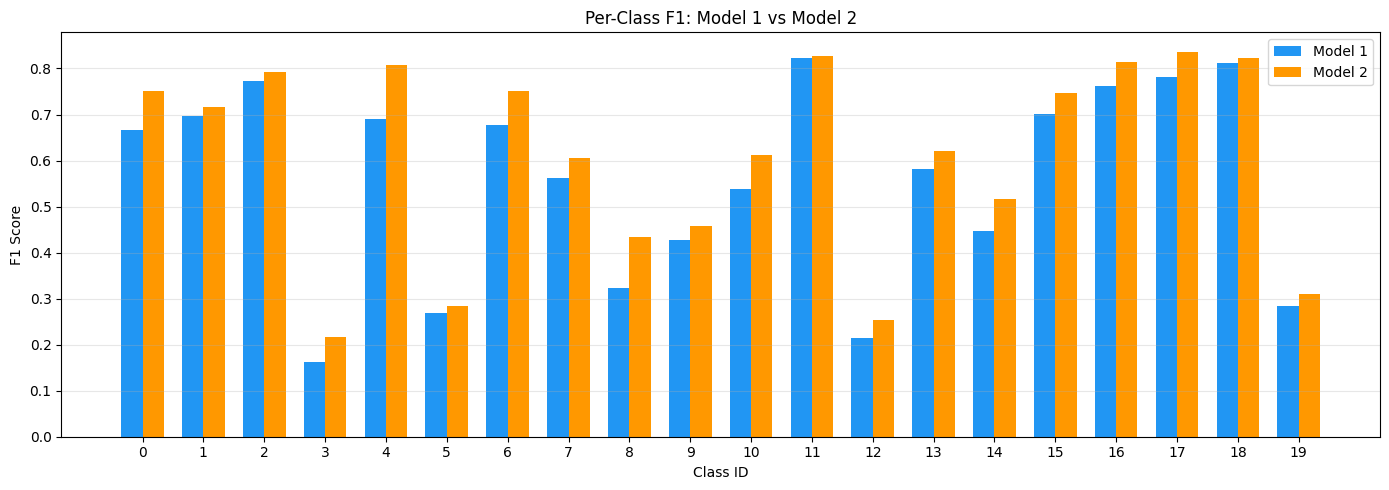

In [12]:
import matplotlib.pyplot as plt

# Merge both models' F1 scores into one DataFrame for easy plotting
# Sorted by class id so the bars line up nicely on the x-axis
plot_df = df1[["class_id", "f1"]].merge(
    df2[["class_id", "f1"]], on="class_id", suffixes=("_m1", "_m2")
).sort_values("class_id")

fig, ax = plt.subplots(figsize=(14, 5))

# Place Model 1 and Model 2 bars side by side for each class
x = np.arange(len(plot_df))
bar_width = 0.35

ax.bar(x - bar_width / 2, plot_df["f1_m1"], bar_width, label="Model 1", color="#2196F3")
ax.bar(x + bar_width / 2, plot_df["f1_m2"], bar_width, label="Model 2", color="#FF9800")

ax.set_xlabel("Class ID")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1: Model 1 vs Model 2")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["class_id"].values)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save for the report
(REPO_ROOT / "analysis" / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(str(REPO_ROOT / "analysis" / "figures" / "model_comparison_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

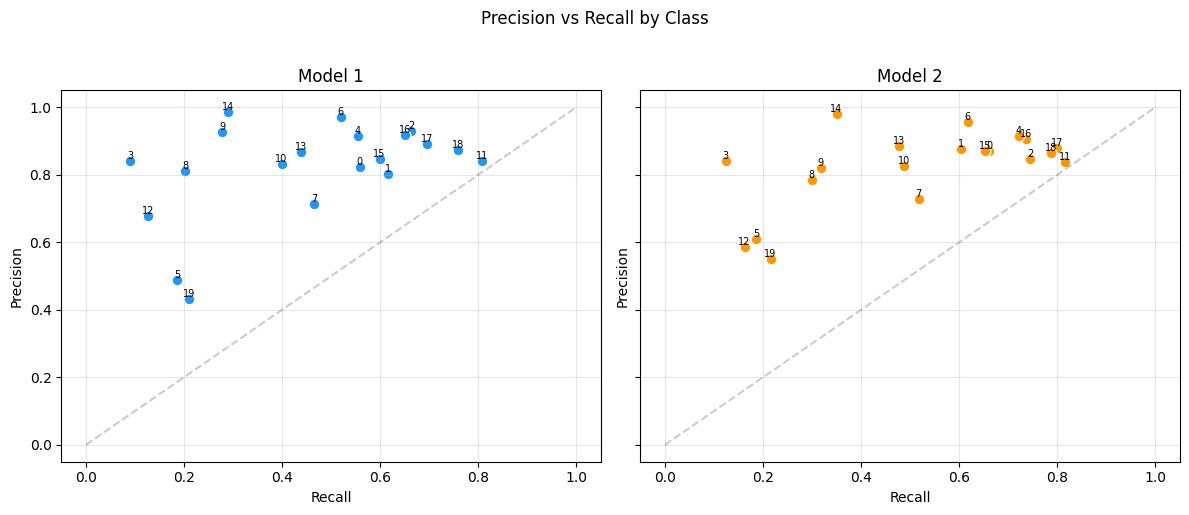

In [13]:
# Scatter plot showing each class as a dot 
# Makes it easy to spot which model has a better precision/recall balance at a glance
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)

for ax, df, name, color in [
    (axes[0], df1, "Model 1", "#2196F3"),
    (axes[1], df2, "Model 2", "#FF9800"),
]:
    ax.scatter(df["recall"], df["precision"], c=color, s=60, edgecolors="white")

    # Label each dot with its class id so we can identify outliers
    for _, row in df.iterrows():
        ax.annotate(int(row["class_id"]), (row["recall"], row["precision"]),
                     fontsize=7, ha="center", va="bottom")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(name)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Diagonal reference line (points above it have higher precision than recall)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2)

plt.suptitle("Precision vs Recall by Class", y=1.02)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / "analysis" / "figures" / "model_pr_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()